# 05 — Screened ML Trend Sleeve (CL)

## tl;dr

After dropping HG, NQ, ZN and ZT, the CL-only linear-trend sleeve produced positive returns in 4/4 development-validation folds and a session-weighted annualized return of 19.2%. This is a **promising candidate sleeve, not independent proof**: the universe was selected after inspecting these validation folds. The sealed holdout remains untouched.

## Context & Methods

The same 20-feature pooled Ridge design is retained, but the active model universe is CL. HG was removed after its predictive association failed to translate into stable portfolio contribution. NQ, ZN and ZT were removed for unstable forecast association and contribution.

### Key assumptions

- Five-session normalized-return forecast with expanding walk-forward fitting.
- One-session execution delay and 3.5 bps placeholder costs.
- CL sleeve exposure capped at ±25% of the master portfolio.
- Results are selection-conditional and may not be described as untouched OOS.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
ROOT = Path.cwd().parent if Path.cwd().name == 'outputs' else Path.cwd()
PORT = ROOT / 'data/processed/portfolios'
summary = pd.read_csv(PORT / 'ml_trend_screened_walk_forward_summary.csv')
screen = pd.read_csv(PORT / 'ml_trend_universe_screen.csv')
screen

,symbol,decision,basis
0,CLU6,retain,positive forecast association in all four vali...
1,HGU6,drop,forecast association did not survive portfolio...
2,NQU6,drop,unstable rank association and net contribution
3,ZNU6,drop,unstable directional accuracy and net contribu...
4,ZTU6,drop,negative average rank association and net cont...


## Results

In [2]:
summary.round(4)

,fold,sessions,annualized_return,annualized_volatility,sharpe,maximum_drawdown,average_gross,average_net,average_daily_turnover
0,1,63,0.4442,0.0816,5.4406,-0.0189,0.2123,-0.1399,0.0396
1,2,63,0.0550,0.0774,0.7105,-0.0407,0.2500,-0.0516,0.0317
2,3,63,0.0014,0.1270,0.0106,-0.0624,0.1975,0.1201,0.0258
3,4,37,0.3198,0.0633,5.0485,-0.0087,0.2050,0.0445,0.0073


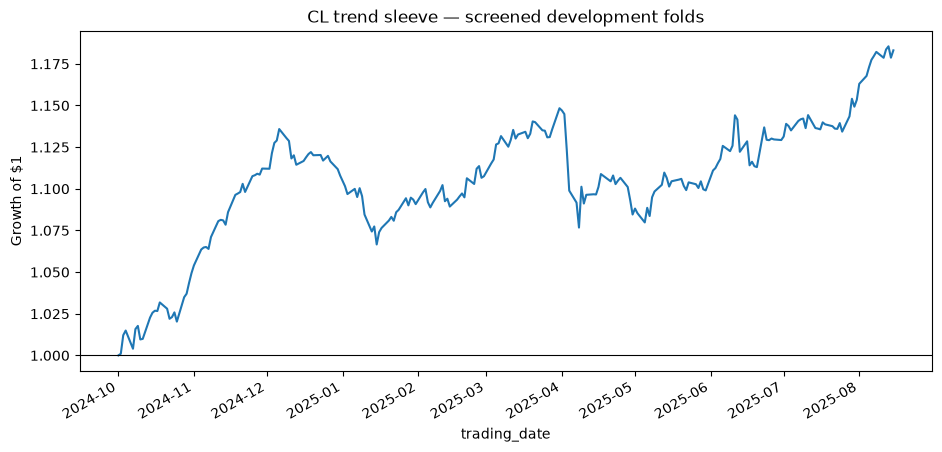

In [3]:
returns = pd.read_parquet(PORT / 'ml_trend_screened_portfolio_returns.parquet')['net_return']
folds = pd.read_csv(ROOT / 'outputs/development_walk_forward_folds.csv')
mask = pd.Series(False, index=returns.index)
for row in folds.itertuples():
    mask.loc[pd.Timestamp(row.validation_start):pd.Timestamp(row.validation_end)] = True
equity = (1 + returns[mask]).cumprod()
ax = equity.plot(figsize=(11, 5), title='CL trend sleeve — screened development folds')
ax.axhline(1.0, color='black', lw=.8); ax.set_ylabel('Growth of $1'); plt.show()

## Takeaways

1. CL is the only instrument that currently satisfies the working-sleeve requirement.
2. The result is stable in sign across all four folds, but fold 3 is essentially flat.
3. CL is a capped sleeve, not a diversified portfolio by itself.
4. Before holdout use, the CL inclusion rule must be frozen and execution costs calibrated in ticks/contracts.
5. The master portfolio needs additional independently validated sleeves or instruments.